# Computing the probability distribution of ring parameters from observed stellar density
## By Jorge I. Zuluaga, Jaime Alvarado-Montes, Sebastian Numpaque-Rodríguez and David Kipping

## Modules required

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('GeoTrans')
from geotrans2 import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
import pickle
from scipy.stats import norm
from tqdm import tqdm
import warnings
import multiprocess as mp
from scipy.stats import multivariate_normal
from ipywidgets import interact, FloatSlider
import time
from copy import deepcopy
import os
warnings.filterwarnings("ignore")

## Routines

In [2]:
def mcra_grid_general(S,props,store,adjust,Np,seed=None,verbose=False,default=False):
    
    # Noauto 
    noauto = S.noauto
    S.noauto = True

    # Seed 
    if seed is not None:
        np.random.seed(seed)

    # Arrays to store the values:
    Xs = []

    # Initialize spar
    # Store complimentary information
    spars = dict()
    for sprop,vals in store.items():
        spars[sprop] = getattr(S,vals['prop'])*vals['scale']

    # Maximum value of probabilities
    p_delta_max = 1/((2*np.pi)**0.5*S.delta_std)
    p_rho_obs_max = S.rho_obs_fun.y.max()
    if verbose:print(f"Maximum probabilities: p_delta_max: {p_delta_max}, p_rho_obs_max: {p_rho_obs_max}")

    i=0 # Main counter 
    n=0 # Counter of failed tests
    n_acceptances = [] # Number of tests before acceptance
    while i<Np:

        if verbose:print(f"Testing point: {n}")
        n+=1

        # Get a random point
        pars = dict()
        for prop,vals in props.items():
            if default:
                pars[prop] = vals['default']*vals['scale']
            else:
                pars[prop] = np.random.uniform(vals['range'][0], vals['range'][1]) * vals['scale']
        S.__dict__.update(pars)

        # Adjust parameters
        adjust(S)

        msg = ""
        for prop,vals in props.items():
            msg += f"{prop}: {getattr(S,prop)/vals['scale']}, "
        if verbose:print(f"Guess parameters: {msg.strip(', ')}")

        # Update system
        S.updateSystem()
        S.calculate_PR()

        # Store complimentary information
        spars = dict()
        for sprop,vals in store.items():
            spars[sprop] = getattr(S,vals['prop'])*vals['scale']

        # Compute probabilities
        p_rho_obs = float(S.rho_obs_fun(spars['rho_obs']))
        p_delta = float(S.delta_fun(spars['delta']))

        if verbose:print(f"\trho_obs: {spars['rho_obs']}, rho_true: {spars['rho_true']}, PR: {spars['PR']}, delta: {spars['delta']} (target {S.delta_mean})")
        if verbose:print(f"\tProbabilities: p_rho_obs: {p_rho_obs}, p_delta: {p_delta}")

        # Acceptance ratio
        alpha = p_rho_obs*p_delta / (p_rho_obs_max*p_delta_max)
        if verbose:print(f"\tAcceptance ratio: {alpha}")

        # Accept or reject
        u = np.random.rand()
        if verbose:print(f"\tRandom number: {u}")
        if u < alpha:
            # Sample parameters
            values = [pars[prop]/vals['scale'] for prop,vals in props.items()]
            svalues = [spars[prop] for prop in store.keys()]
            Xs.append(values + svalues)
            if verbose:print("\tAccepted")
            i += 1
            n_acceptances += [n]
            n = 0
        else:
            if verbose:print("\t\tRejected")

    if verbose:print(f"Acceptance rate: {np.mean(n_acceptances)} test per accepted sample")
    columns = [prop for prop,vals in props.items()]
    scolumns = [prop for prop,vals in spars.items()]
    Xs = pd.DataFrame(Xs,columns=columns + scolumns)

    S.noauto = noauto

    return Xs

def parallel_mcra_grid(S, props, store, adjust, num_processes=1, Ns=100):
    
    # Define the number of iterations for each process
    num_iterations = Ns // num_processes

    # Function to run the grid
    def run_grid(seed):
        return mcra_grid_general(S, props, store, adjust, num_iterations, seed=seed)

    # Launch the grids in parallel
    with mp.Pool(processes=num_processes) as pool:
        results = pool.map(run_grid, range(num_processes))

    # Combine the results
    Xs = pd.concat(results, ignore_index=True)

    return Xs

def plotSample(Xs,S,props,rho_range=(500,4000),chargs=dict(),csargs=dict(),prefix="noprefix"):
    # ################################################
    # TARGET DISTRIBUTIONS
    # ################################################
    fig, axs = plt.subplots(1, 3, figsize=(12, 6))

    # First subplot
    axs[0].hist(Xs['rho_obs'], bins=30, density=True, alpha=0.5, label='MCMC Samples')
    x = np.linspace(500,4000,400)
    y = S.rho_obs_fun(x)
    axs[0].plot(x, y, 'r--', label='Interpolated Observed Density')
    y_true = S.rho_true_fun(x)
    axs[0].plot(x, y_true, 'b--', label='Interpolated True Density')
    axs[0].set_xlim(*rho_range)
    axs[0].set_xlabel(r'Observed Density [kg/m$^3$]')
    axs[0].set_ylabel('Frequency')
    axs[0].legend()

    # Second subplot
    axs[1].hist(Xs['delta'], bins=30, density=True, alpha=0.5, label='MCMC Samples')
    delta_values = np.linspace(Xs['delta'].min(), Xs['delta'].max(), 400)
    gaussian = S.delta_fun(delta_values)
    axs[1].plot(delta_values, gaussian, 'r--', label='Gaussian Distribution')
    axs[1].set_xlabel('Delta')
    axs[1].set_ylabel('Frequency')
    axs[1].legend()

    # Third subplot
    axs[2].hist(Xs['rho_true'], bins=4, density=True, alpha=0.5, label='MCMC Samples')
    x = np.linspace(500,4000,400)
    y = S.rho_true_fun(x)
    axs[2].plot(x, y, 'r--', label='Interpolated True Density')
    axs[2].set_xlim(*rho_range)
    axs[2].set_xlabel(r'True Density [kg/m$^3$]')
    axs[2].set_ylabel('Frequency')
    axs[2].legend()

    plt.tight_layout()
    plt.savefig(f"figures/target_distributions-{prefix}.png")
    plt.show()

    # ################################################
    # PARAMETER'S CONTOURS
    # ################################################
    columns = [prop for prop,vals in props.items()]
    data = np.array(Xs[columns])

    G=PlotGrid(props,figsize=3)

    hargs=dict(alpha=1,bins=10,density=False,colorbar=1,cmap="rainbow")
    hargs.update(chargs)
    G.plotHist(data,**hargs)

    sargs=dict(c='r',marker='.',s=2,edgecolors='none',alpha=0.3)
    sargs.update(csargs)
    G.scatterPlot(data,**sargs)
    G.fig.savefig(f"figures/corner_posteriors-{prefix}.png")

    # ################################################
    # PARAMETER'S POSTERIORS
    # ################################################
    fig, axs = plt.subplots(1, len(props), figsize=(18, 6))

    for i, (prop, vals) in enumerate(props.items()):
        axs[i].hist(Xs[prop], bins=30, density=True, alpha=0.5, label=prop)
        axs[i].set_xlabel(prop)
        axs[i].set_ylabel('Frequency')
        axs[i].set_title(f'Histogram of {prop}')
        axs[i].legend()

    plt.tight_layout()
    plt.savefig(f"figures/parameters_posteriors-{prefix}.png")
    plt.show()

## Extract system properties

### Load all densities

In [3]:
# Unpickle the functions
with open('rho_true_fun.pkl', 'rb') as f:
    rho_true_fun = pickle.load(f)

with open('rho_obs_b_fun.pkl', 'rb') as f:
    rho_obs_b_fun = pickle.load(f)

with open('rho_obs_c_fun.pkl', 'rb') as f:
    rho_obs_c_fun = pickle.load(f)

with open('rho_obs_d_fun.pkl', 'rb') as f:
    rho_obs_d_fun = pickle.load(f)

All densities

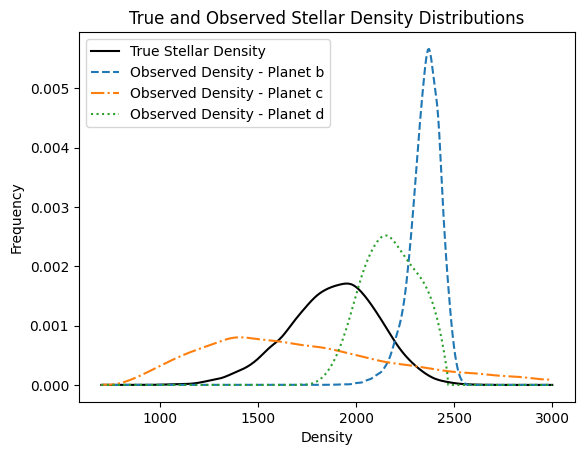

In [4]:
# Define the range for x-axis
x_range = np.linspace(700, 3000, 400)

# Plot rho_true_fun
plt.plot(x_range, rho_true_fun(x_range), label='True Stellar Density', color='black')

# Plot rho_obs_*_fun for each planet
plt.plot(x_range, rho_obs_b_fun(x_range), label='Observed Density - Planet b', linestyle='--')
plt.plot(x_range, rho_obs_c_fun(x_range), label='Observed Density - Planet c', linestyle='-.')
plt.plot(x_range, rho_obs_d_fun(x_range), label='Observed Density - Planet d', linestyle=':')

# Decoration
plt.xlabel('Density')
plt.ylabel('Frequency')
plt.title('True and Observed Stellar Density Distributions')
plt.legend()
plt.show()

## Stellar grid

In [5]:
df = pd.read_csv('Kepler-51/GKTHCatalog_Table4.csv')
k51 = df[df['id_starname'] == 'kic11773022']

rho_true_sun = MSUN/(4/3 * np.pi * RSUN**3)

M_mean = k51.iso_mass.values[0]
R_mean = k51.iso_rad.values[0]
M_std = (k51.iso_mass_err1.values[0] + abs(k51.iso_mass_err2.values[0]))/2
R_std = (k51.iso_rad_err1.values[0] + abs(k51.iso_rad_err2.values[0]))/2

Ms_mean = M_mean*MSUN
Ms_std = M_std*MSUN
Rs_mean = R_mean*RSUN
Rs_std = R_std*RSUN

print(f"Mass: {M_mean} +/- {M_std}")
print(f"Radius: {R_mean} +/- {R_std}")

# Mass grid
Ng = 5
ts = 2
MS, RS = np.meshgrid(
    np.linspace(Ms_mean - ts*Ms_std, Ms_mean + ts*Ms_std, Ng)/MSUN,
    np.linspace(Rs_mean - ts*Rs_std, Rs_mean + ts*Rs_std, Ng)/RSUN
)
delta_Ms = MS[0,1] - MS[0,0]
delta_Rs = RS[1,0] - RS[0,0]

mean = [M_mean, R_mean]
rho_MR = -0.2
cov = [
    [M_std**2, rho_MR * M_std * R_std], 
    [rho_MR * M_std * R_std, R_std**2]
]
PS = np.zeros(MS.shape)
for i in range(MS.shape[0]):
    for j in range(RS.shape[1]):
        PS[i, j] = multivariate_normal.pdf([MS[i, j], RS[i, j]], mean=mean, cov=cov)
PS = PS*delta_Ms*delta_Rs

Mass: 0.9146640833784588 +/- 0.04980093747925855
Radius: 0.8688315952605846 +/- 0.02891379267492005


## Sampling functions and parameters

In [6]:
Nw = 4

def adjust_params(S,verbose=False):
    # Given Porb and Mstar calculate ap
    S.ap = ((GCONST * S.Mstar * S.Porb_mean**2) / (4 * pi**2))**(1/3)
    if verbose:print(f"Semimajor axis: {S.ap/AU:.4f} au = {S.ap/S.Rstar:.2f} Rs")

    # Given Borb and ap calculate iorb
    S.iorb = np.arccos(S.borb_mean*S.Rstar/S.ap)
    if verbose:print(f"Orbital inclination: {S.iorb*RAD:.2f} degrees")

    S.updateSystem()

## Planet information

In [7]:
# https://exoplanetarchive.ipac.caltech.edu/overview/Kepler-51
# Planet b: Masuda et al. 2024

system_prefix = 'k51-planet_c'
rho_obs_fun = rho_obs_c_fun

# Columns are: Rp/R*, rho* (km/m^3), b, P (ignore), tmid,0 (ignore), q1, q2
data = np.loadtxt('Kepler-51/Kepler-51d_85d/TTVplan-post_equal_weights.dat')

# Planetary radius
Rp_mean = 0.57*RJUP # Masuda et al. 2024
Rp_std = 0.12*RJUP/2 # Masuda et al. 2024

# Orbital period
Porb_mean = 85.3139*DAY # Masuda et al. 2024
Porb_std = 0.0020*DAY # Masuda et al. 2024

# Impact parameter
borb_mean = 0.72 # 0.9880 # Masuda et al. 2024
borb_std = 0.0200 # Masuda et al. 2024

# Planetary mass
Mp_mean = 0.0178*MJUP
Mp_std = 0.0025*MJUP


### Build system

In [8]:
# ============================
# TRANSIT DEPTH
# ============================
delta_mean = (Rp_mean/Rs_mean)**2
delta_std = 2*delta_mean*(Rp_std/Rp_mean + Rs_std/Rs_mean)
print(f"Transit depth: {delta_mean*100:.2f} +/- {delta_std*100:.2f} %")

# ============================
# SEMIMAJOR AXIS
# ============================
# Semimajor axis
ap_mean = ((GCONST * Ms_mean * Porb_mean**2) / (4 * pi**2))**(1/3)
ap_std = 1/3*ap_mean*(Ms_std/Ms_mean + 2*Porb_std/Porb_mean)
print(f"Semimajor axis: {ap_mean/AU:.4f} +/- {ap_std/AU:.4f} au = {ap_mean/Rs_mean:.2f} Rs")

# ============================
# ORBITAL INCLINATION
# ============================
iorb_mean = np.arccos(borb_mean*Rs_mean/ap_mean)*RAD
iorb_std = np.sqrt((borb_std * Rs_mean / ap_mean)**2 + \
                   (borb_mean * Rs_std / ap_mean)**2 + \
                   (borb_mean * Rs_mean * ap_std / ap_mean**2)**2) * RAD
print(f"Orbital inclination: {iorb_mean:.2f} +/- {iorb_std:.2f} degrees")

# ============================
# MINIMUM PLANET RADIUS
# ============================
Rp_min = REARTH*(Mp_mean/MEARTH)**(1/3)
fRp_min = Rp_min/Rp_mean
print(f"Minimum planet radius: {Rp_min/RJUP:.4f} RJup")
print(f"Minimum planet radius in terms of the ringless planet radius: {fRp_min:.4f} Rp")

System = RingedSystem(
    system = dict(
        Mstar=Ms_mean,
        Rstar=Rs_mean,
        Rplanet=Rp_mean, # Libby-Roberts et al. 2020
        Mplanet=Mp_mean, # Libby-Roberts et al. 2020
        ap=ap_mean, #Semi-major axis # Libby-Roberts et al. 2020
        iorb=iorb_mean*DEG, #Orbital inclination
        fe=1, #Exterior ring (Rp)
        fi=1, #Interior ring (Rp)
        ir=0.0*DEG, #Ring inclination
        phir=0.0*DEG, #Ring roll angle
        tau=1.0, #Opacity
    )
)

System.noauto = True

# Useful functions
System.Porb_mean = Porb_mean
System.borb_mean = borb_mean
System.delta_mean = delta_mean
System.delta_std = delta_std
System.delta_fun = lambda x:norm.pdf(x, delta_mean, delta_std)
System.rho_obs_fun = rho_obs_fun
System.rho_true_fun = rho_true_fun

# Adjust
print()
print("After adjustment:")
adjust_params(System,True)

System.calculate_PR()
print(f"rho_obs: {System.rho_obs}, rho_true: {System.rho_true}, PR: {System.PR}")

Transit depth: 0.43 +/- 0.12 %
Semimajor axis: 0.3682 +/- 0.0067 au = 91.04 Rs
Orbital inclination: 89.55 +/- 0.02 degrees
Minimum planet radius: 0.1624 RJup
Minimum planet radius in terms of the ringless planet radius: 0.2849 Rp

After adjustment:
Semimajor axis: 0.3682 au = 91.04 Rs
Orbital inclination: 89.55 degrees
rho_obs: 1960.544897598225, rho_true: 1960.8074257658545, PR: -5.8150620150464134e-05


## Parameters: fe, Rp, ir, phir

Describe parameter space:

In [9]:
# Parameter space
props = dict(
    fe = dict(
        label=r"$f_e$",
        range=[1.1,6.0],
        scale=1,
    ),
    Rplanet = dict(
        label=r"$R_p$ [$R_{jup}$]",
        range=[fRp_min*Rp_mean/RJUP, Rp_mean/RJUP],
        scale=RJUP,
    ),
    ir = dict(
        label=r"$i_r$ [deg]",
        range=[0.0, 90.0],
        scale=DEG,
    ),
    phir = dict(
        label=r"$\phi_r$ [deg]",
        range=[0.0, 90.0],
        scale=DEG,
    ),
)

# Parameters to store
store_params = dict(
    # Basic
    rho_true = dict(prop='rho_true',scale=1),
    rho_obs = dict(prop='rho_obs',scale=1),
    PR = dict(prop='PR',scale=1),
    ieff = dict(prop='ieff',scale=RAD),
    teff = dict(prop='teff',scale=RAD),
    delta = dict(prop='Ar',scale=1/np.pi),
    # Other
    Rstar = dict(prop='Rstar',scale=1/RSUN),
    Mstar = dict(prop='Mstar',scale=1/MSUN),
    ap = dict(prop='ap',scale=1/AU),
    ep = dict(prop='ep',scale=1),
    iorb = dict(prop='iorb',scale=RAD),
    Borb = dict(prop='Borb',scale=1),
    Porb = dict(prop='Porb',scale=1/DAY),
    tT = dict(prop='tT',scale=1),
    grazing = dict(prop='grazing',scale=1),
)

Sampling:

In [10]:
S = deepcopy(System)
S.tau = 1
S.fi = 1

# Total size of the sample
Ns = int(1e6)

# Name of the sample
sample_suffix = f"MR_simple_variance-N{Ns:.0e}"

# Prepare the data
columns = [prop for prop,vals in props.items()]
Xs = pd.DataFrame([],columns=columns + ['rho_true', 'rho_obs', 'PR', 'ieff', 'teff', 'delta'])

# Loop over the grid
Nsamples = 0
n = 0 
for i in range(MS.shape[0]):
    for j in range(RS.shape[1]):
        n += 1 

        # Update stellar parameters
        S.Mstar = MS[i, j]*MSUN
        S.Rstar = RS[i, j]*RSUN
        S.updateSystem()
        
        # Calculate the number of samples required
        Np = int(PS[i,j]*Ns)
        
        print(f"Stellar parameters {n}: M_star = {S.Mstar/MSUN}, R_star = {S.Rstar/RSUN}, Number of samples: {Np}")

        start_time = time.time()
        results = parallel_mcra_grid(S, props, store_params, adjust_params, Nw, Np)
        end_time = time.time()
        execution_time = end_time - start_time
        print(f"\tExecution time: {execution_time:.2f} seconds")

        Nsamples += len(results)

        # Accumulate
        Xs = pd.concat([Xs,results], ignore_index=True)
        
        # Save accumulated
        Xs.to_csv(f"tmp/ringed_sample-{system_prefix}-{sample_suffix}.csv", index=False)
    
#os.system('say "Tu programa ha terminado"')

Stellar parameters 1: M_star = 0.8150622084199416, R_star = 0.8110040099107445, Number of samples: 1094
	Execution time: 6.47 seconds
Stellar parameters 2: M_star = 0.8648631458992002, R_star = 0.8110040099107445, Number of samples: 7920
	Execution time: 42.03 seconds
Stellar parameters 3: M_star = 0.9146640833784587, R_star = 0.8110040099107445, Number of samples: 20225
	Execution time: 101.94 seconds
Stellar parameters 4: M_star = 0.9644650208577173, R_star = 0.8110040099107445, Number of samples: 18224
	Execution time: 94.57 seconds
Stellar parameters 5: M_star = 1.014265958336976, R_star = 0.8110040099107445, Number of samples: 5794
	Execution time: 31.82 seconds
Stellar parameters 6: M_star = 0.8150622084199416, R_star = 0.8399178025856646, Number of samples: 7920
	Execution time: 34.97 seconds
Stellar parameters 7: M_star = 0.8648631458992002, R_star = 0.8399178025856646, Number of samples: 46538
	Execution time: 202.99 seconds
Stellar parameters 8: M_star = 0.9146640833784587, R

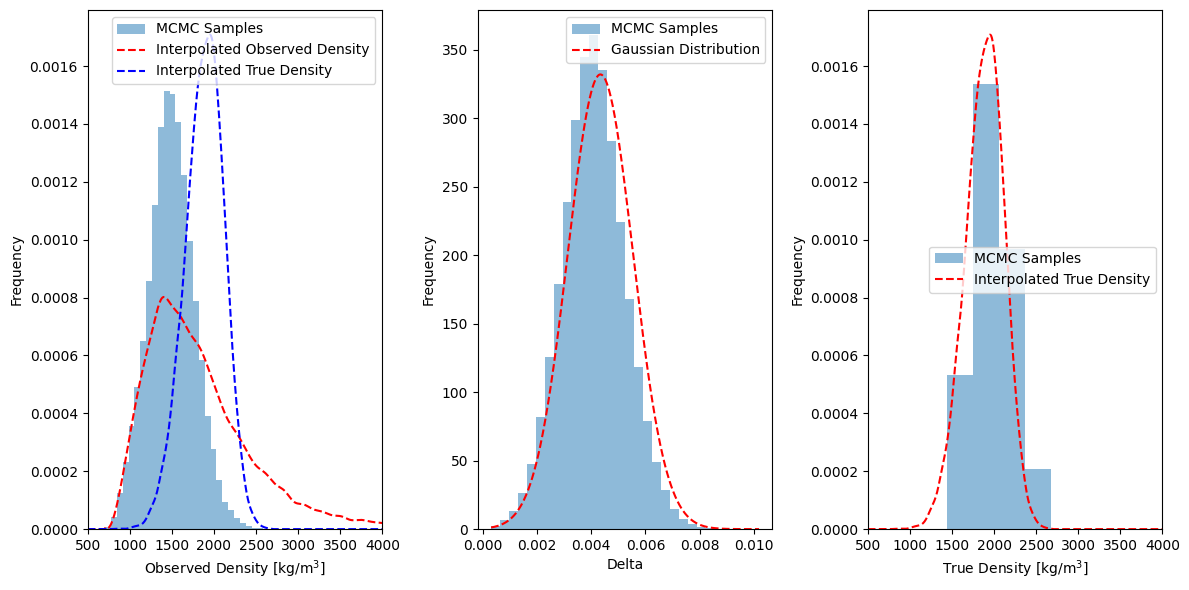

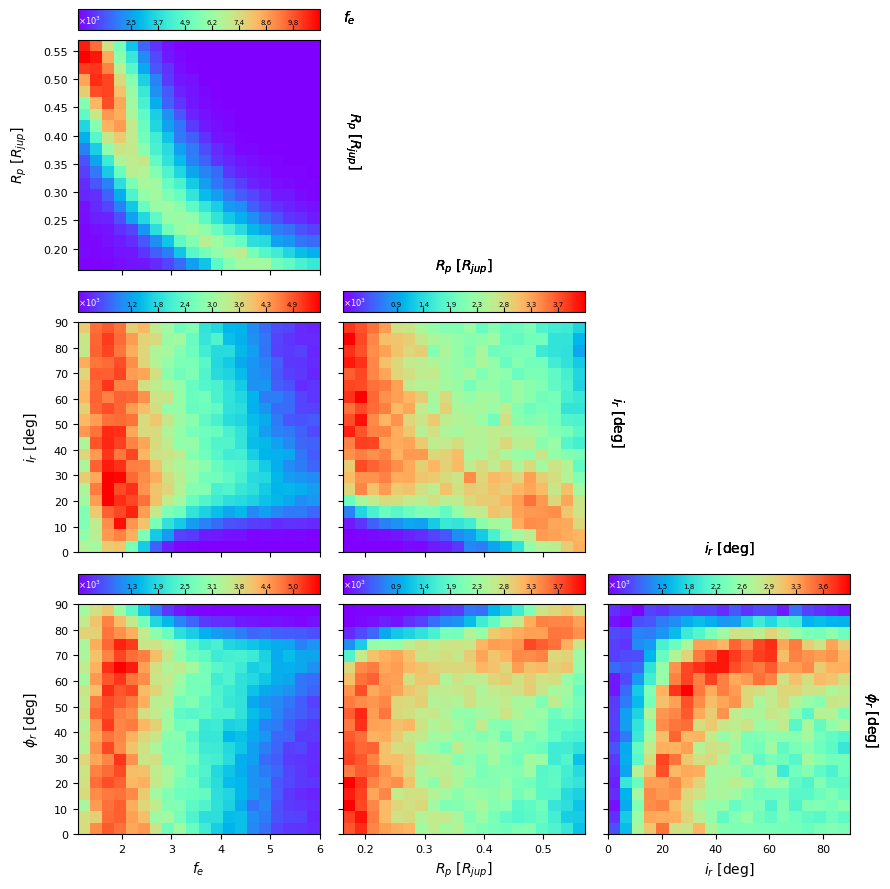

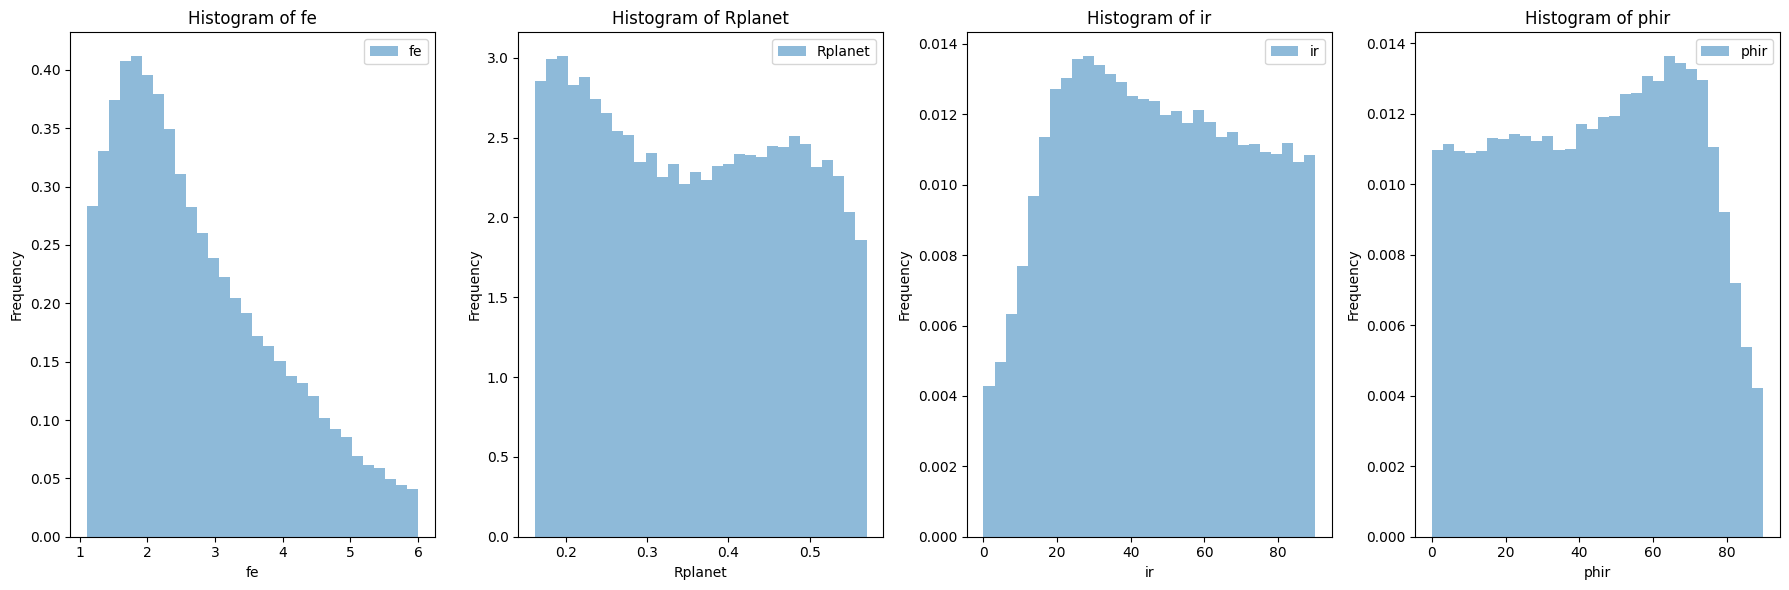

In [11]:
Xs = pd.read_csv(f"tmp/ringed_sample-{system_prefix}-{sample_suffix}.csv")
plotSample(Xs,S,props,prefix=f"{system_prefix}-{sample_suffix}",
           csargs=dict(alpha=0),chargs=dict(bins=20))

Alternative plot:

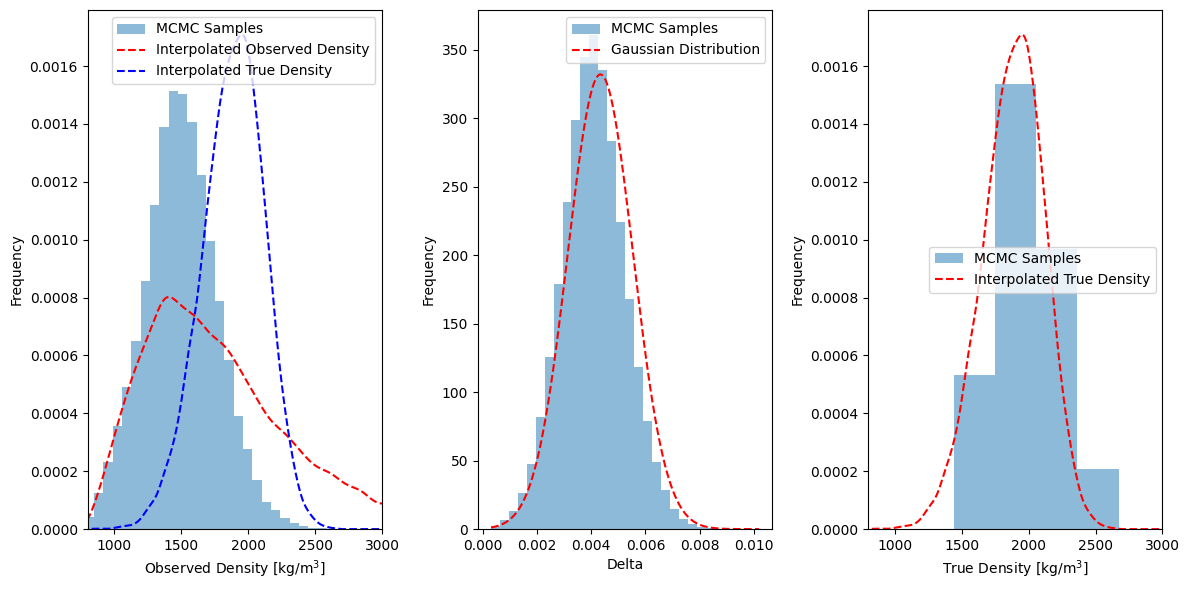

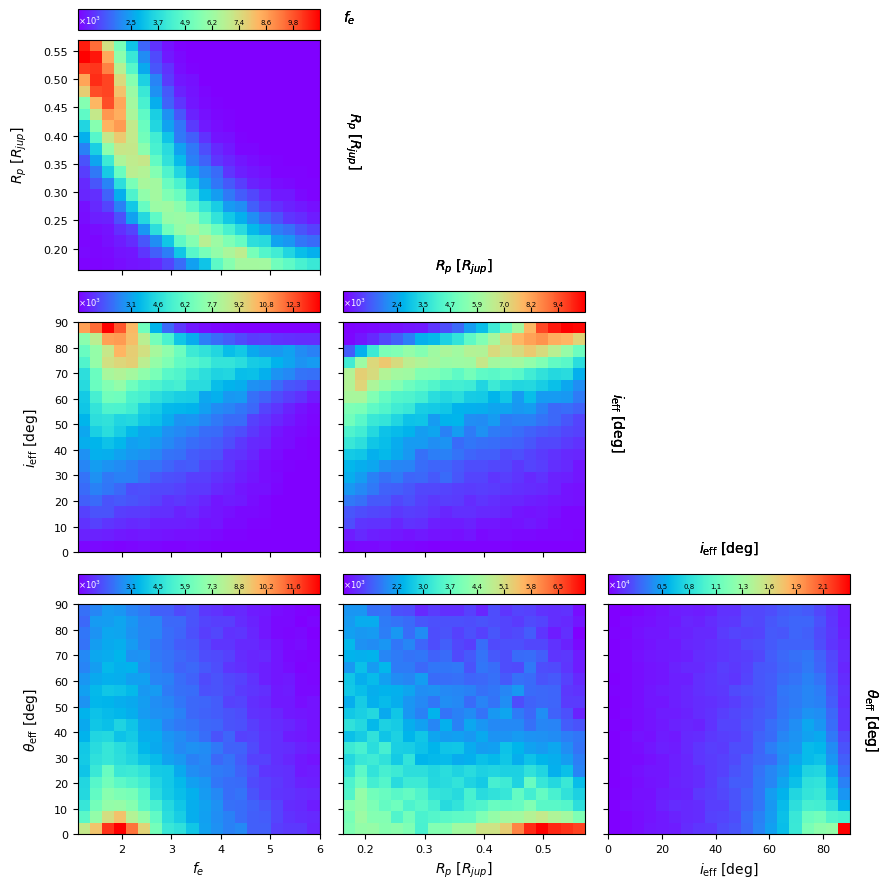

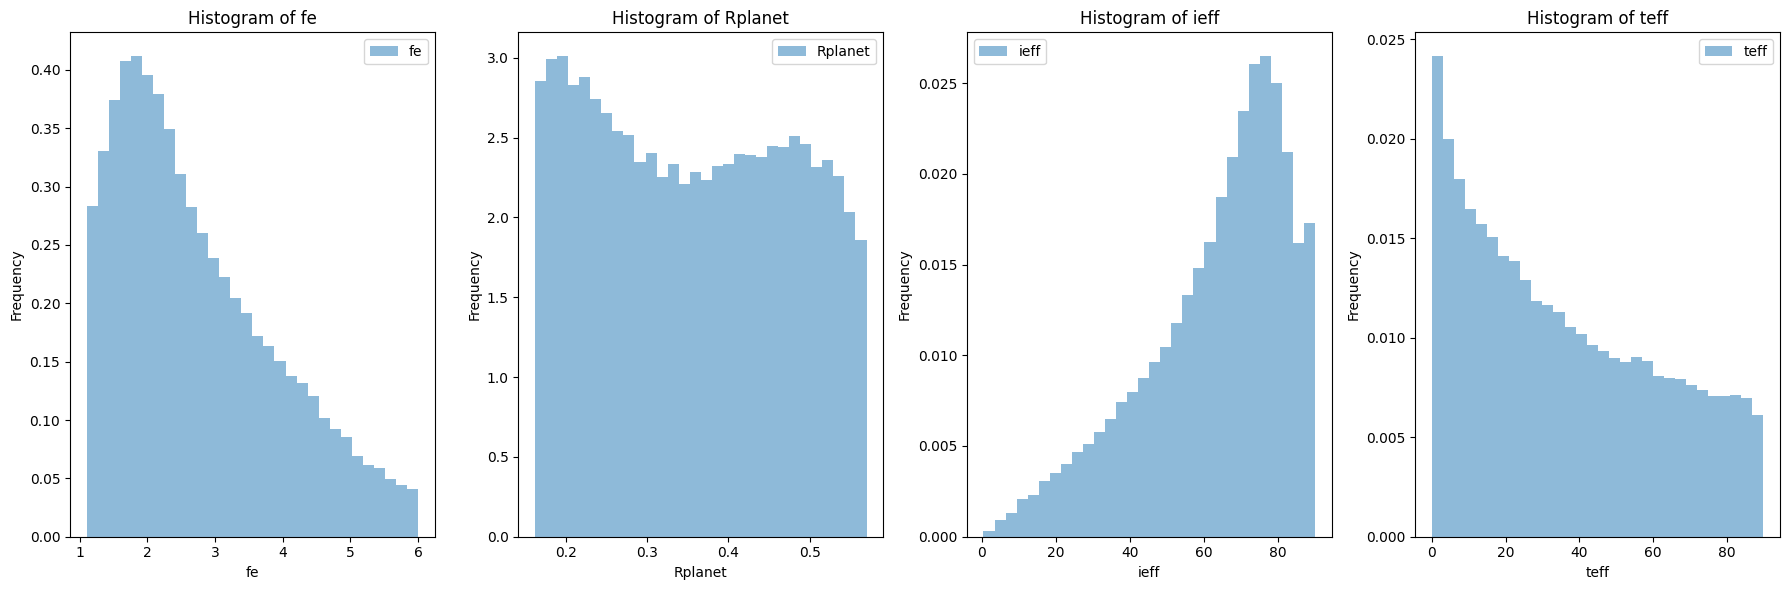

In [12]:
altprops = dict(
    fe = props['fe'],
    Rplanet = props['Rplanet'],
    ieff = dict(
        label=r"$i_{\rm eff}$ [deg]",
        range=[0,90],
    ),
    teff = dict(
        label=r"$\theta_{\rm eff}$ [deg]",
        range=[0,90],
    )
)
plotSample(Xs,S,altprops,prefix=f"{system_prefix}-{sample_suffix}-veff",rho_range=(800,3000),
           csargs=dict(alpha=0),chargs=dict(bins=20))

## Fixed radius

In [13]:
# Parameter space
props = dict(
    fe = dict(
        label=r"$f_e$",
        range=[2.0,10.0],
        scale=1,
    ),
    ir = dict(
        active=1,
        label=r"$i_r$ [deg]",
        range=[0.0, 90.0],
        scale=DEG,
    ),
    phir = dict(
        active=1,
        label=r"$\phi_r$ [deg]",
        range=[0.0, 90.0],
        scale=DEG,
    ),
)

# Parameters to store
store_params = dict(
    # Basic
    rho_true = dict(prop='rho_true',scale=1),
    rho_obs = dict(prop='rho_obs',scale=1),
    PR = dict(prop='PR',scale=1),
    ieff = dict(prop='ieff',scale=RAD),
    teff = dict(prop='teff',scale=RAD),
    delta = dict(prop='Ar',scale=1/np.pi),
    # Other
    Rplanet = dict(prop='Rplanet',scale=1/RJUP),
    Rstar = dict(prop='Rstar',scale=1/RSUN),
    Mstar = dict(prop='Mstar',scale=1/MSUN),
    ap = dict(prop='ap',scale=1/AU),
    ep = dict(prop='ep',scale=1),
    iorb = dict(prop='iorb',scale=RAD),
    Borb = dict(prop='Borb',scale=1),
    Porb = dict(prop='Porb',scale=1/DAY),
    tT = dict(prop='tT',scale=1),
    grazing = dict(prop='grazing',scale=1),
)

System.Rplanet = Rp_min

Sampling:

In [14]:
S = deepcopy(System)
S.tau = 1
S.fi = 1

# Total size of the sample
Ns = int(1e6)
Nw = 4

# Name of the sample
sample_suffix = f"MR_simple_variance_NoRp-N{Ns:.0e}"

# Prepare the data
columns = [prop for prop,vals in props.items()]
Xs = pd.DataFrame([],columns=columns + ['rho_true', 'rho_obs', 'PR', 'ieff', 'teff', 'delta'])

# Loop over the grid
Nsamples = 0
n = 0 
for i in range(MS.shape[0]):
    for j in range(RS.shape[1]):
        n += 1 

        # Update stellar parameters
        S.Mstar = MS[i, j]*MSUN
        S.Rstar = RS[i, j]*RSUN
        S.updateSystem()
        
        # Calculate the number of samples required
        Np = int(PS[i,j]*Ns)
        
        print(f"Stellar parameters {n}: M_star = {S.Mstar/MSUN}, R_star = {S.Rstar/RSUN}, Number of samples: {Np}")

        start_time = time.time()
        results = parallel_mcra_grid(S, props, store_params, adjust_params, Nw, Np)
        end_time = time.time()
        execution_time = end_time - start_time
        print(f"\tExecution time: {execution_time:.2f} seconds")

        Nsamples += len(results)

        # Accumulate
        Xs = pd.concat([Xs,results], ignore_index=True)
        
        # Save accumulated
        Xs.to_csv(f"tmp/ringed_sample-{system_prefix}-{sample_suffix}.csv", index=False)
    
# os.system('say "Tu programa ha terminado"')

Stellar parameters 1: M_star = 0.8150622084199416, R_star = 0.8110040099107445, Number of samples: 1094
	Execution time: 3.74 seconds
Stellar parameters 2: M_star = 0.8648631458992002, R_star = 0.8110040099107445, Number of samples: 7920
	Execution time: 24.65 seconds
Stellar parameters 3: M_star = 0.9146640833784587, R_star = 0.8110040099107445, Number of samples: 20225
	Execution time: 63.90 seconds
Stellar parameters 4: M_star = 0.9644650208577173, R_star = 0.8110040099107445, Number of samples: 18224
	Execution time: 61.33 seconds
Stellar parameters 5: M_star = 1.014265958336976, R_star = 0.8110040099107445, Number of samples: 5794
	Execution time: 20.86 seconds
Stellar parameters 6: M_star = 0.8150622084199416, R_star = 0.8399178025856646, Number of samples: 7920
	Execution time: 24.60 seconds
Stellar parameters 7: M_star = 0.8648631458992002, R_star = 0.8399178025856646, Number of samples: 46538
	Execution time: 139.71 seconds
Stellar parameters 8: M_star = 0.9146640833784587, R_

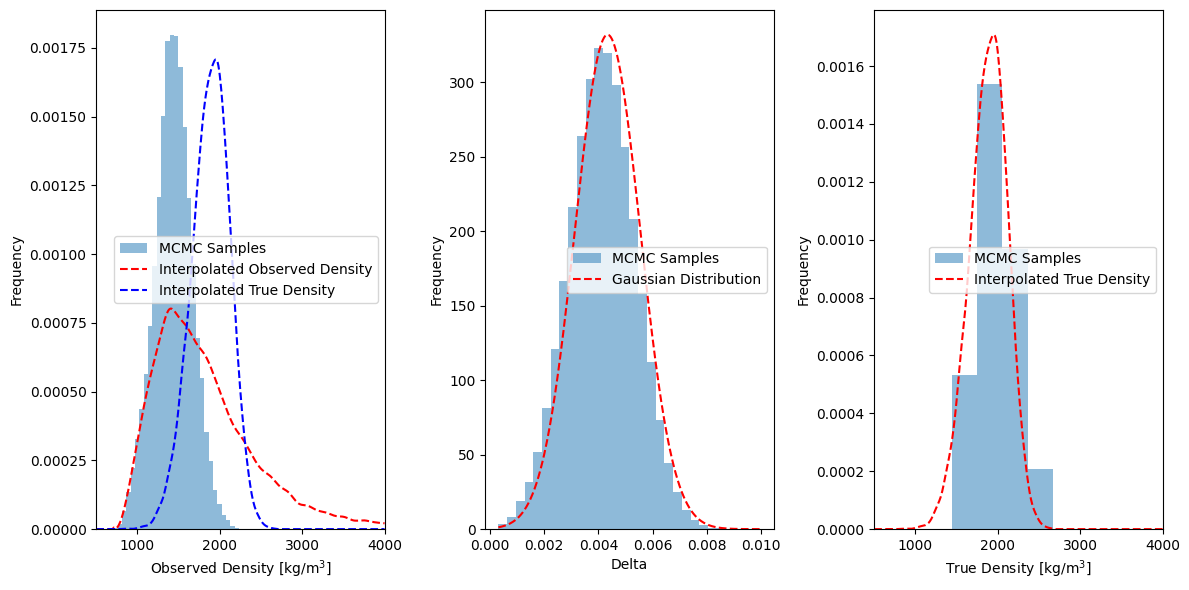

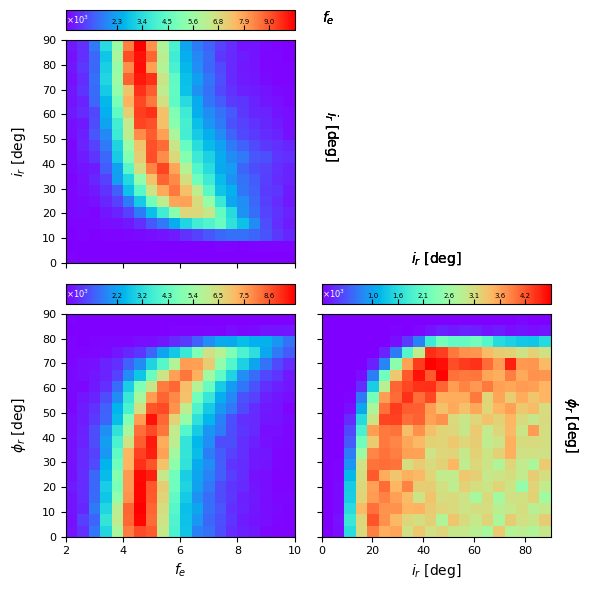

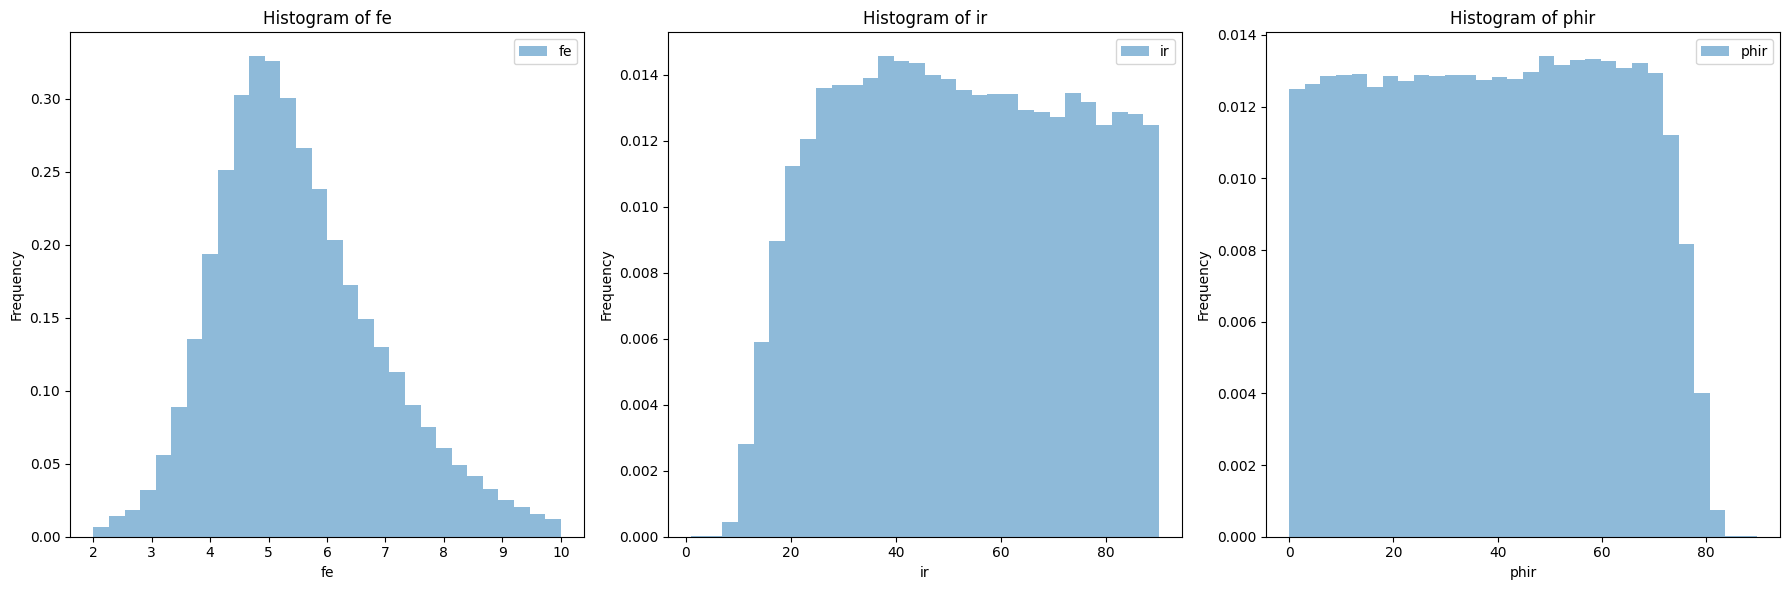

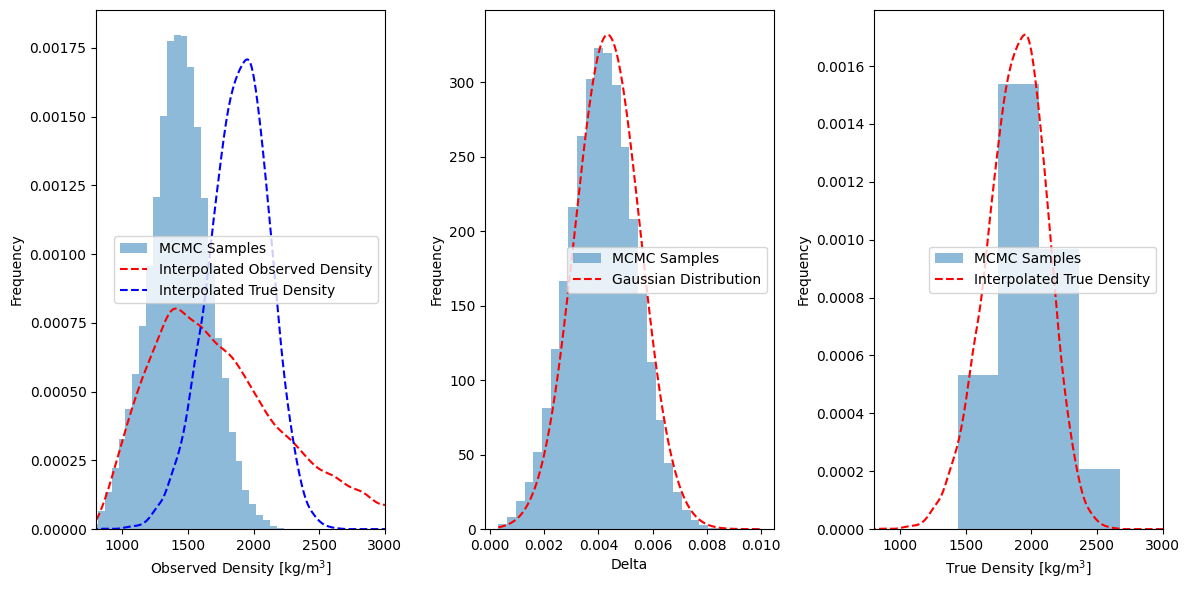

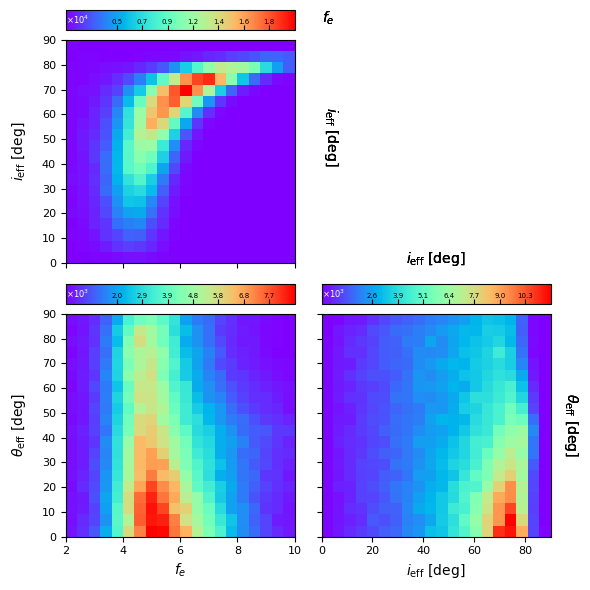

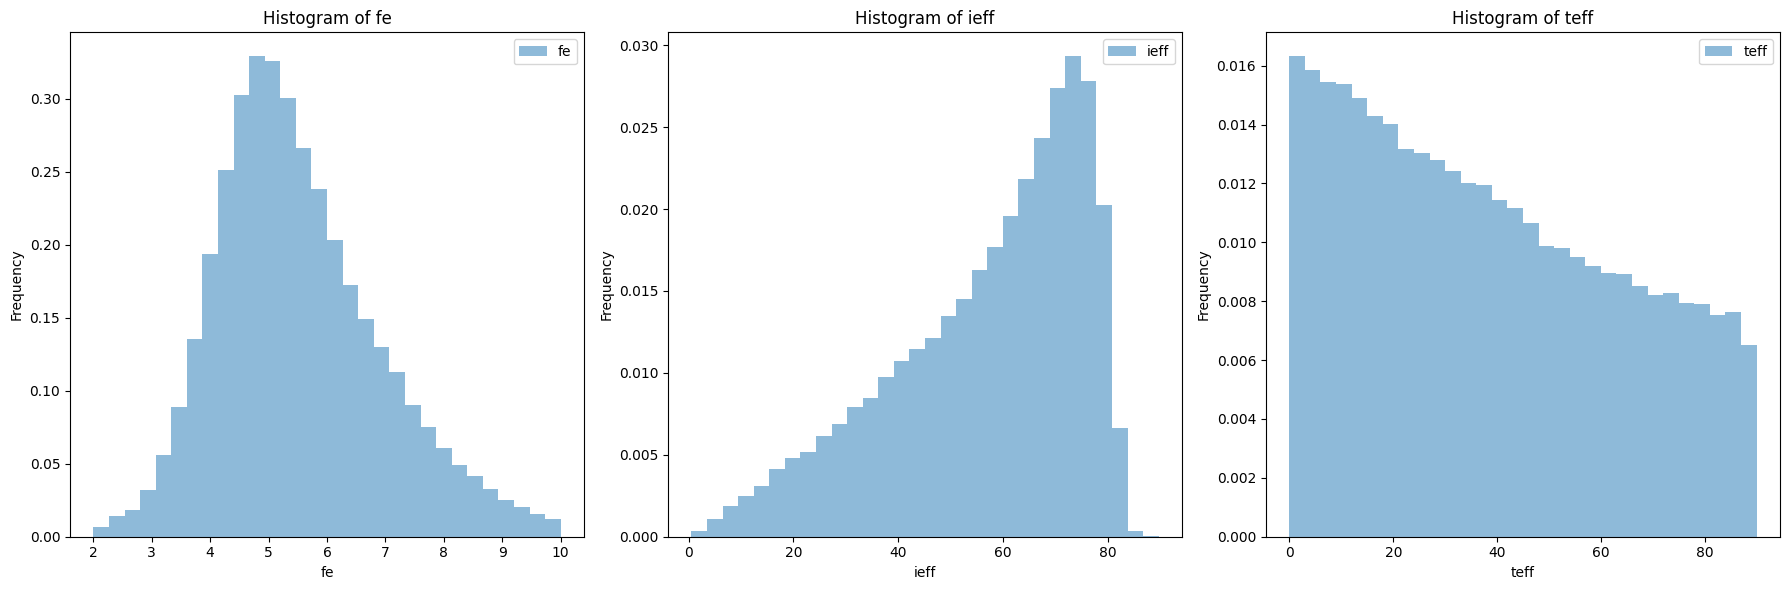

In [15]:
Xs = pd.read_csv(f"tmp/ringed_sample-{system_prefix}-{sample_suffix}.csv")
plotSample(Xs,S,props,prefix=f"{system_prefix}-{sample_suffix}",
           csargs=dict(alpha=0),chargs=dict(bins=20))

altprops = dict(
    fe = props['fe'],
    ieff = dict(
        label=r"$i_{\rm eff}$ [deg]",
        range=[0,90],
    ),
    teff = dict(
        label=r"$\theta_{\rm eff}$ [deg]",
        range=[0,90],
    )
)
plotSample(Xs,S,altprops,prefix=f"{system_prefix}-{sample_suffix}-veff",rho_range=(800,3000),
           csargs=dict(alpha=0),chargs=dict(bins=20))

## Tau variation

In [16]:
# Parameter space
props = dict(
    tau = dict(
        label=r"$\tau$",
        range=[1.0,10.0],
        scale=1,
    ),
    fe = dict(
        label=r"$f_e$",
        range=[1.1,10.0],
        scale=1,
    ),
    ir = dict(
        active=1,
        label=r"$i_r$ [deg]",
        range=[0.0, 90.0],
        scale=DEG,
    ),
    phir = dict(
        label=r"$\phi_r$ [deg]",
        range=[0.0, 90.0],
        scale=DEG,
    ),
)

# Parameters to store
store_params = dict(
    # Basic
    rho_true = dict(prop='rho_true',scale=1),
    rho_obs = dict(prop='rho_obs',scale=1),
    PR = dict(prop='PR',scale=1),
    ieff = dict(prop='ieff',scale=RAD),
    teff = dict(prop='teff',scale=RAD),
    delta = dict(prop='Ar',scale=1/np.pi),
    # Other
    Rplanet = dict(prop='Rplanet',scale=1/RJUP),
    Rstar = dict(prop='Rstar',scale=1/RSUN),
    Mstar = dict(prop='Mstar',scale=1/MSUN),
    ap = dict(prop='ap',scale=1/AU),
    ep = dict(prop='ep',scale=1),
    iorb = dict(prop='iorb',scale=RAD),
    Borb = dict(prop='Borb',scale=1),
    Porb = dict(prop='Porb',scale=1/DAY),
    tT = dict(prop='tT',scale=1),
    grazing = dict(prop='grazing',scale=1),
)

Sampling:

In [17]:
S = deepcopy(System)
S.tau = 1
S.fi = 1

# Total size of the sample
Ns = int(1e6)
Nw = 4

# Name of the sample
sample_suffix = f"MR_simple_variance_NoRp_tau-N{Ns:.0e}"

# Prepare the data
columns = [prop for prop,vals in props.items()]
Xs = pd.DataFrame([],columns=columns + ['rho_true', 'rho_obs', 'PR', 'ieff', 'teff', 'delta'])

# Loop over the grid
Nsamples = 0
n = 0 
for i in range(MS.shape[0]):
    for j in range(RS.shape[1]):
        n += 1 

        # Update stellar parameters
        S.Mstar = MS[i, j]*MSUN
        S.Rstar = RS[i, j]*RSUN
        S.updateSystem()
        
        # Calculate the number of samples required
        Np = int(PS[i,j]*Ns)
        
        print(f"Stellar parameters {n}: M_star = {S.Mstar/MSUN}, R_star = {S.Rstar/RSUN}, Number of samples: {Np}")

        start_time = time.time()
        results = parallel_mcra_grid(S, props, store_params, adjust_params, Nw, Np)
        end_time = time.time()
        execution_time = end_time - start_time
        print(f"\tExecution time: {execution_time:.2f} seconds")

        Nsamples += len(results)

        # Accumulate
        Xs = pd.concat([Xs,results], ignore_index=True)
        
        # Save accumulated
        Xs.to_csv(f"tmp/ringed_sample-{system_prefix}-{sample_suffix}.csv", index=False)

Stellar parameters 1: M_star = 0.8150622084199416, R_star = 0.8110040099107445, Number of samples: 1094
	Execution time: 5.45 seconds
Stellar parameters 2: M_star = 0.8648631458992002, R_star = 0.8110040099107445, Number of samples: 7920
	Execution time: 34.56 seconds
Stellar parameters 3: M_star = 0.9146640833784587, R_star = 0.8110040099107445, Number of samples: 20225
	Execution time: 93.38 seconds
Stellar parameters 4: M_star = 0.9644650208577173, R_star = 0.8110040099107445, Number of samples: 18224
	Execution time: 88.16 seconds
Stellar parameters 5: M_star = 1.014265958336976, R_star = 0.8110040099107445, Number of samples: 5794
	Execution time: 29.23 seconds
Stellar parameters 6: M_star = 0.8150622084199416, R_star = 0.8399178025856646, Number of samples: 7920
	Execution time: 31.50 seconds
Stellar parameters 7: M_star = 0.8648631458992002, R_star = 0.8399178025856646, Number of samples: 46538
	Execution time: 185.41 seconds
Stellar parameters 8: M_star = 0.9146640833784587, R_

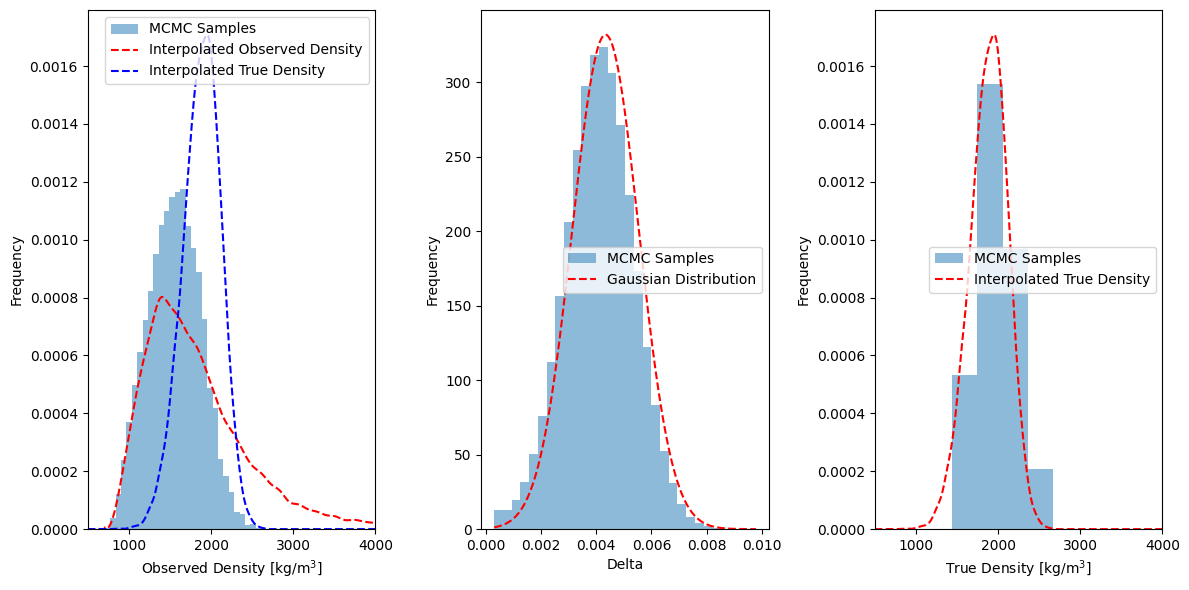

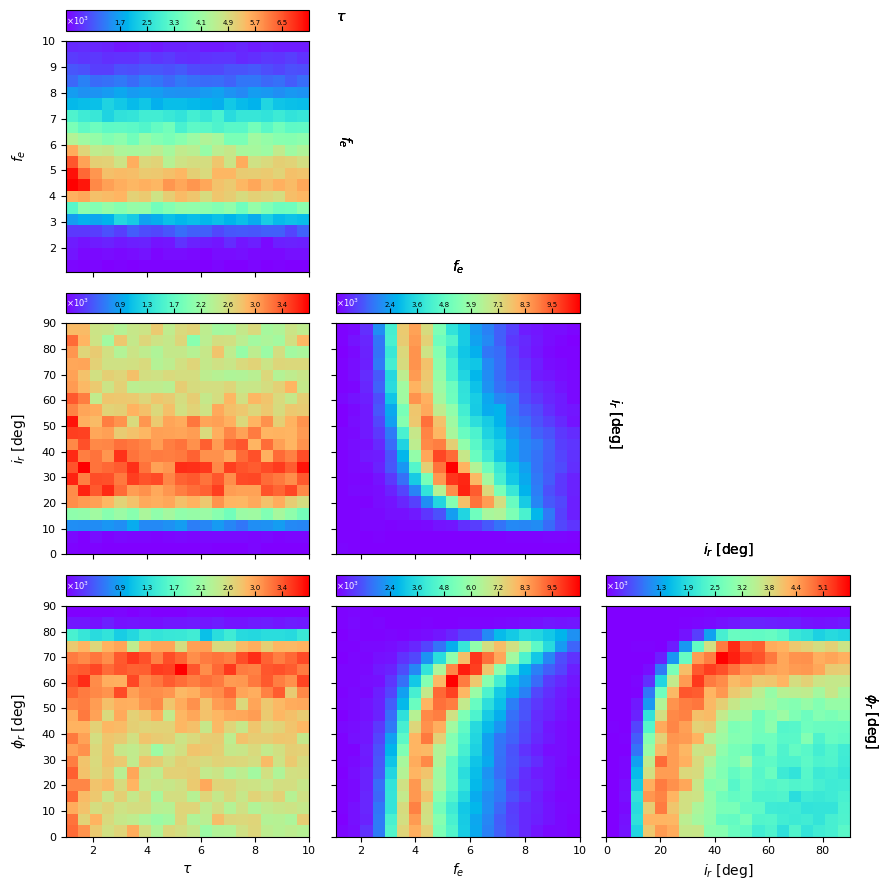

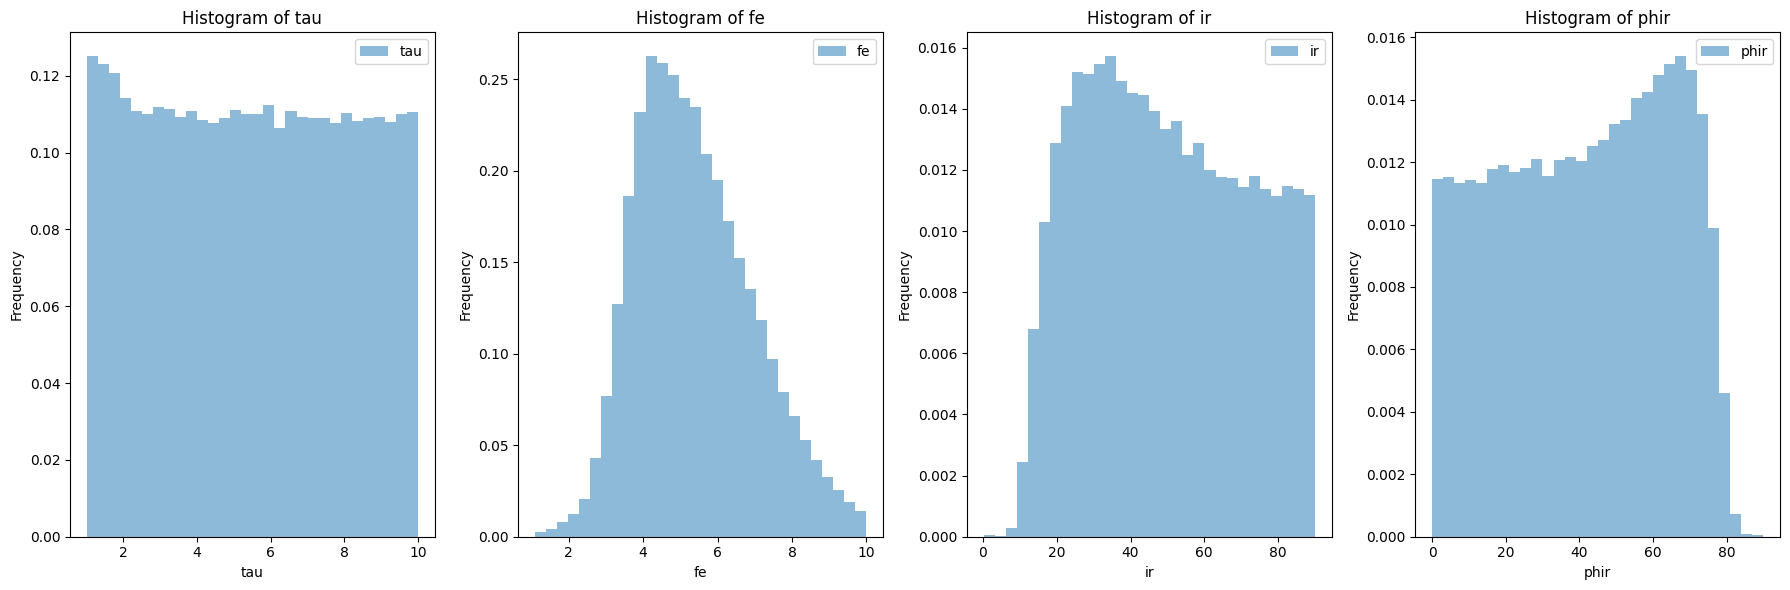

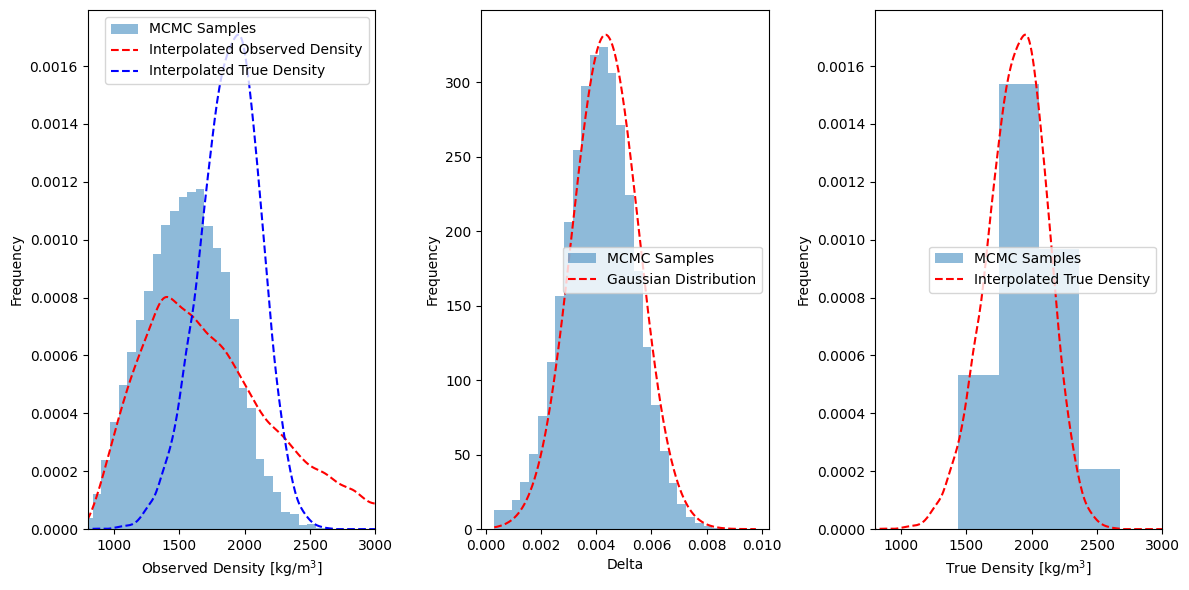

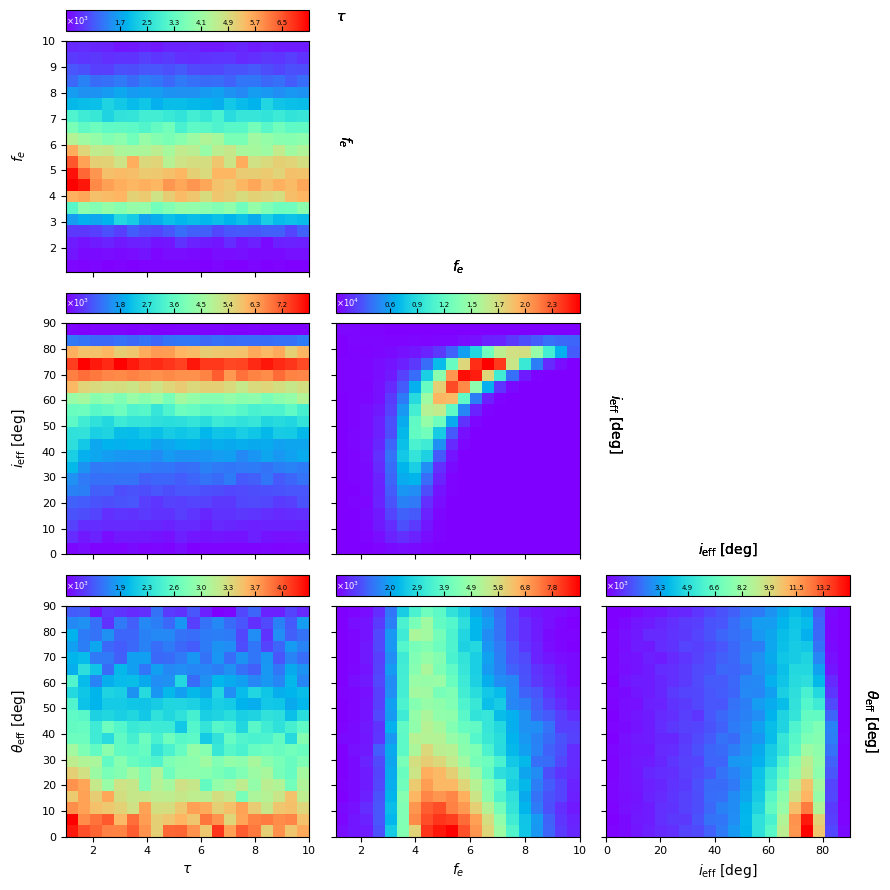

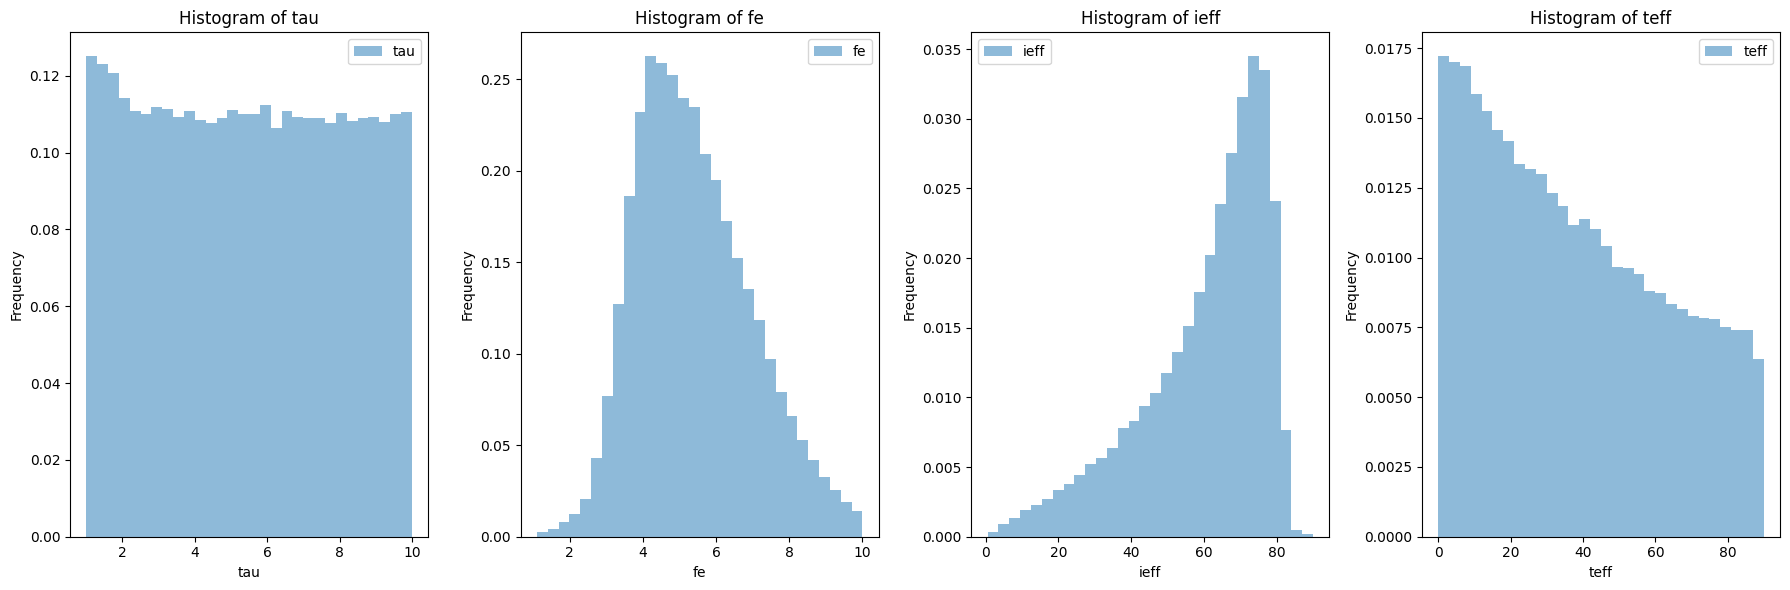

In [18]:
Xs = pd.read_csv(f"tmp/ringed_sample-{system_prefix}-{sample_suffix}.csv")
plotSample(Xs,S,props,prefix=f"{system_prefix}-{sample_suffix}",
           csargs=dict(alpha=0),chargs=dict(bins=20))

altprops = dict(
    tau = props['tau'],
    fe = props['fe'],
    ieff = dict(
        label=r"$i_{\rm eff}$ [deg]",
        range=[0,90],
    ),
    teff = dict(
        label=r"$\theta_{\rm eff}$ [deg]",
        range=[0,90],
    )
)
plotSample(Xs,S,altprops,prefix=f"{system_prefix}-{sample_suffix}-veff",rho_range=(800,3000),
           csargs=dict(alpha=0),chargs=dict(bins=20))

The end:

In [19]:
os.system('say "Tu programa ha terminado"')

0